In [1]:
import math
import os
import random
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('CUDA devices:', torch.cuda.device_count())


Torch: 2.9.0+cu126
CUDA available: True
CUDA devices: 2


## Configuration

In [2]:
DATA_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
SAVE_DIR  = '/kaggle/working/mae_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_SIZE   = 224
PATCH_SIZE   = 16
MASK_RATIO   = 0.75
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1.5e-4
WEIGHT_DECAY = 0.05
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
SEED         = 42
AMP          = True


## Persistent Checkpoint Setup (Kaggle Dataset)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PERSISTENT CHECKPOINT SAVER
# Saves checkpoints to a Kaggle Dataset so they survive session loss /
# page refresh / network disconnect.
#
# ONE-TIME SETUP (do this before running training):
#   1. Go to  https://www.kaggle.com/datasets/new
#   2. Create an empty dataset called  mae-checkpoints
#   3. Come back here and set KAGGLE_USERNAME to your Kaggle username
# ─────────────────────────────────────────────────────────────────────────────

KAGGLE_USERNAME = 'aishaygull'   # <── change this
DATASET_NAME    = 'mae-checkpoints'
DATASET_DIR     = f'/kaggle/working/{DATASET_NAME}'
os.makedirs(DATASET_DIR, exist_ok=True)

def push_to_kaggle_dataset(src_path: str, filename: str) -> bool:
    """
    Copy *src_path* into the dataset staging folder and push it to Kaggle.
    Returns True on success, False if the push failed (training continues).
    """
    import shutil, subprocess, json, tempfile

    # 1. Copy file into staging folder
    dst = os.path.join(DATASET_DIR, filename)
    shutil.copy2(src_path, dst)

    # 2. Write dataset-metadata.json (required by Kaggle API)
    meta = {
        "title": DATASET_NAME,
        "id": f"{KAGGLE_USERNAME}/{DATASET_NAME}",
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(os.path.join(DATASET_DIR, 'dataset-metadata.json'), 'w') as f:
        json.dump(meta, f)

    # 3. Push via Kaggle CLI
    try:
        result = subprocess.run(
            ['kaggle', 'datasets', 'version',
             '-p', DATASET_DIR,
             '-m', f'auto-save {filename}',
             '--dir-mode', 'zip'],
            capture_output=True, text=True, timeout=120
        )
        if result.returncode == 0:
            print(f'  [kaggle] pushed {filename} to dataset ✓')
            return True
        else:
            print(f'  [kaggle] push failed: {result.stderr.strip()}')
            return False
    except Exception as e:
        print(f'  [kaggle] push error: {e}')
        return False

print('Kaggle persistent-save helper ready.')
print(f'Dataset target: {KAGGLE_USERNAME}/{DATASET_NAME}')


Kaggle persistent-save helper ready.
Dataset target: aishaygull/mae-checkpoints


## Utilities and Dataset

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class TinyImageNetSelfSupervised(Dataset):
    def __init__(self, root: str, split: str = 'train', image_size: int = 224):
        self.root = Path(root)
        self.split = split
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

        if split == 'train':
            self.image_paths = sorted((self.root / 'train').glob('*/images/*.JPEG'))
        elif split == 'val':
            self.image_paths = sorted((self.root / 'val' / 'images').glob('*.JPEG'))
        else:
            raise ValueError('split must be train or val')

        if len(self.image_paths) == 0:
            raise FileNotFoundError(f'No images found under {self.root} for split={split}')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)


## MAE Model (Base PyTorch Layers)

In [5]:
class MLP(nn.Module):
    def __init__(self, dim: int, mlp_ratio: float = 4.0, drop: float = 0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.fc2(x))
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio=mlp_ratio)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size    = img_size
        self.patch_size  = patch_size
        self.grid_size   = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MAEViT(nn.Module):
    def __init__(
        self,
        img_size=224, patch_size=16, in_chans=3,
        enc_dim=768,  enc_depth=12, enc_heads=12,
        dec_dim=384,  dec_depth=12, dec_heads=6,
        mask_ratio=0.75,
    ):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.in_chans   = in_chans
        self.mask_ratio = mask_ratio

        self.patch_embed  = PatchEmbed(img_size, patch_size, in_chans, enc_dim)
        self.num_patches  = self.patch_embed.num_patches
        self.patch_dim    = patch_size * patch_size * in_chans

        self.enc_pos_embed  = nn.Parameter(torch.zeros(1, self.num_patches, enc_dim))
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(enc_dim, enc_heads) for _ in range(enc_depth)
        ])
        self.enc_norm = nn.LayerNorm(enc_dim)

        self.enc_to_dec  = nn.Linear(enc_dim, dec_dim)
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.dec_pos_embed  = nn.Parameter(torch.zeros(1, self.num_patches, dec_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(dec_dim, dec_heads) for _ in range(dec_depth)
        ])
        self.dec_norm = nn.LayerNorm(dec_dim)
        self.dec_pred = nn.Linear(dec_dim, self.patch_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.enc_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.dec_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token,    std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def patchify(self, imgs):
        p = self.patch_size
        b, c, h, w = imgs.shape
        x = imgs.reshape(b, c, h // p, p, w // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).contiguous()
        x = x.reshape(b, (h // p) * (w // p), p * p * c)
        return x

    def unpatchify(self, patches):
        p = self.patch_size
        b, n, _ = patches.shape
        h = w = int(math.sqrt(n))
        x = patches.reshape(b, h, w, p, p, self.in_chans)
        x = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        return x.reshape(b, self.in_chans, h * p, w * p)

    def random_masking(self, x):
        b, n, d = x.shape
        len_keep = int(n * (1.0 - self.mask_ratio))
        noise        = torch.rand(b, n, device=x.device)
        ids_shuffle  = torch.argsort(noise, dim=1)
        ids_restore  = torch.argsort(ids_shuffle, dim=1)
        ids_keep     = ids_shuffle[:, :len_keep]
        x_vis        = torch.gather(x, 1, ids_keep.unsqueeze(-1).repeat(1, 1, d))
        mask         = torch.ones([b, n], device=x.device)
        mask[:, :len_keep] = 0
        mask         = torch.gather(mask, dim=1, index=ids_restore)
        return x_vis, mask, ids_restore

    def forward_encoder(self, imgs):
        x = self.patch_embed(imgs) + self.enc_pos_embed
        x_vis, mask, ids_restore = self.random_masking(x)
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        x_vis = self.enc_norm(x_vis)
        return x_vis, mask, ids_restore

    def forward_decoder(self, x_vis, ids_restore):
        x = self.enc_to_dec(x_vis)
        b, n_vis, d = x.shape
        n_full = ids_restore.shape[1]
        mask_tokens = self.mask_token.repeat(b, n_full - n_vis, 1)
        x_full = torch.cat([x, mask_tokens], dim=1)
        x_full = torch.gather(x_full, 1,
                              ids_restore.unsqueeze(-1).repeat(1, 1, d))
        x_full = x_full + self.dec_pos_embed
        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.dec_norm(x_full)
        return self.dec_pred(x_full)

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        loss_per_patch = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss_per_patch * mask).sum() / mask.sum().clamp(min=1.0)
        return loss, target

    def forward(self, imgs):
        latent, mask, ids_restore = self.forward_encoder(imgs)
        pred                      = self.forward_decoder(latent, ids_restore)
        loss, target              = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask, target


## Metrics, Visualization, and Training Functions

In [6]:
def compute_psnr(img1, img2, max_val=1.0):
    mse = F.mse_loss(img1, img2).item()
    if mse <= 1e-12:
        return 100.0
    return 20.0 * math.log10(max_val / math.sqrt(mse))


def _gaussian_window(window_size, sigma, channels, device):
    coords = torch.arange(window_size, dtype=torch.float32, device=device)
    coords -= window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    w2d = g[:, None] * g[None, :]
    return w2d.expand(channels, 1, window_size, window_size).contiguous()


def compute_ssim(img1, img2, window_size=11, sigma=1.5, data_range=1.0):
    c      = img1.shape[1]
    window = _gaussian_window(window_size, sigma, c, img1.device)
    pad    = window_size // 2
    mu1    = F.conv2d(img1, window, padding=pad, groups=c)
    mu2    = F.conv2d(img2, window, padding=pad, groups=c)
    mu1_sq = mu1.pow(2);  mu2_sq = mu2.pow(2);  mu12 = mu1 * mu2
    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=c) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=c) - mu2_sq
    sigma12   = F.conv2d(img1 * img2, window, padding=pad, groups=c) - mu12
    c1 = (0.01 * data_range) ** 2;  c2 = (0.03 * data_range) ** 2
    ssim_map = ((2*mu12+c1)*(2*sigma12+c2)) / ((mu1_sq+mu2_sq+c1)*(sigma1_sq+sigma2_sq+c2))
    return ssim_map.mean().item()


def apply_patch_mask(imgs, mask, patch_size):
    b, c, h, w = imgs.shape
    gh, gw = h // patch_size, w // patch_size
    out       = imgs.clone()
    mask_grid = mask.reshape(b, gh, gw)
    for bi in range(b):
        for i in range(gh):
            for j in range(gw):
                if mask_grid[bi, i, j] > 0.5:
                    out[bi, :,
                        i*patch_size:(i+1)*patch_size,
                        j*patch_size:(j+1)*patch_size] = 0.0
    return out


def visualize_reconstructions(model, loader, device, output_path, n_samples=5):
    model.eval()
    with torch.no_grad():
        imgs   = next(iter(loader)).to(device)[:n_samples]
        _, pred, mask, _ = model(imgs)
        recon  = model.unpatchify(pred).clamp(0, 1)
        masked = apply_patch_mask(imgs, mask, model.patch_size).clamp(0, 1)

    fig, axes = plt.subplots(n_samples, 3, figsize=(9, 3 * n_samples))
    if n_samples == 1:
        axes = [axes]
    for i in range(n_samples):
        axes[i][0].imshow(masked[i].permute(1, 2, 0).cpu().numpy())
        axes[i][1].imshow(recon[i].permute(1, 2, 0).cpu().numpy())
        axes[i][2].imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
        for j in range(3):
            axes[i][j].axis('off')
    axes[0][0].set_title('Masked Input')
    axes[0][1].set_title('Reconstruction')
    axes[0][2].set_title('Ground Truth')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def train_one_epoch(model, loader, optimizer, scaler, device, amp=True, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    for step, imgs in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', enabled=amp):
            loss, _, _, _ = model(imgs)
            loss = loss.mean()
        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        if step % 100 == 0:
            print(f'Step {step}/{len(loader)} | loss={loss.item():.4f}')
    return total_loss / len(loader)


def evaluate_metrics(model, loader, device, max_batches=10):
    model.eval()
    psnr_vals, ssim_vals = [], []
    with torch.no_grad():
        for bi, imgs in enumerate(loader):
            if bi >= max_batches:
                break
            imgs = imgs.to(device)
            _, pred, _, _ = model(imgs)
            recon = model.unpatchify(pred).clamp(0, 1)
            psnr_vals.append(compute_psnr(recon, imgs))
            ssim_vals.append(compute_ssim(recon, imgs))
    return sum(psnr_vals) / len(psnr_vals), sum(ssim_vals) / len(ssim_vals)


## Dataloaders

In [7]:
seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TinyImageNetSelfSupervised(DATA_ROOT, split='train', image_size=IMAGE_SIZE)
val_ds   = TinyImageNetSelfSupervised(DATA_ROOT, split='val',   image_size=IMAGE_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('Train images:', len(train_ds))
print('Val images:',   len(val_ds))


Train images: 100000
Val images: 10000


## Build Model

In [8]:
model = MAEViT(
    img_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
    enc_dim=768, enc_depth=12, enc_heads=12,
    dec_dim=384, dec_depth=12, dec_heads=6,
    mask_ratio=MASK_RATIO,
)
model = model.to(device)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs via DataParallel')
    model = nn.DataParallel(model)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.amp.GradScaler(enabled=AMP)


Using 2 GPUs via DataParallel


## Train (with auto-save to Kaggle Dataset)

In [9]:
epoch_losses = []
best_loss    = float('inf')

# ── Resume from checkpoint if one already exists in the dataset ──────────────
START_EPOCH = 1
resume_path = os.path.join(SAVE_DIR, 'mae_last.pt')
if os.path.exists(resume_path):
    print(f'Resuming from {resume_path} ...')
    ckpt_resume = torch.load(resume_path, map_location=device)
    raw_model   = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(ckpt_resume['model_state'])
    optimizer.load_state_dict(ckpt_resume['optimizer_state'])
    scheduler.load_state_dict(ckpt_resume['scheduler_state'])
    START_EPOCH  = ckpt_resume['epoch'] + 1
    best_loss    = ckpt_resume['loss']
    epoch_losses = ckpt_resume.get('epoch_losses', [])
    print(f'Resumed from epoch {ckpt_resume["epoch"]} | best_loss={best_loss:.4f}')
else:
    print('No checkpoint found — starting fresh.')

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(START_EPOCH, EPOCHS + 1):
    avg_loss = train_one_epoch(
        model=model, loader=train_loader, optimizer=optimizer,
        scaler=scaler, device=device, amp=AMP, grad_clip=GRAD_CLIP,
    )
    scheduler.step()
    epoch_losses.append(avg_loss)
    print(f'Epoch {epoch}/{EPOCHS} | avg_loss={avg_loss:.4f}')

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    ckpt = {
        'epoch':           epoch,
        'model_state':     raw_model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'loss':            avg_loss,
        'epoch_losses':    epoch_losses,
        'config': {
            'image_size':  IMAGE_SIZE,
            'patch_size':  PATCH_SIZE,
            'mask_ratio':  MASK_RATIO,
        },
    }

    # 1. Always save locally first (fast)
    last_path = os.path.join(SAVE_DIR, 'mae_last.pt')
    torch.save(ckpt, last_path)

    is_best = avg_loss < best_loss
    if is_best:
        best_loss = avg_loss
        best_path = os.path.join(SAVE_DIR, 'mae_best.pt')
        torch.save(ckpt, best_path)

    # 2. Push to Kaggle Dataset every epoch (survives session loss)
    push_to_kaggle_dataset(last_path, 'mae_last.pt')
    if is_best:
        push_to_kaggle_dataset(best_path, 'mae_best.pt')
        print(f'  ★ New best saved and pushed  (loss={best_loss:.4f})')

print('Training complete.')


No checkpoint found — starting fresh.


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0/3125 | loss=0.3981
Step 100/3125 | loss=0.0721
Step 200/3125 | loss=0.0640
Step 300/3125 | loss=0.0678
Step 400/3125 | loss=0.0757
Step 500/3125 | loss=0.0468
Step 600/3125 | loss=0.0519
Step 700/3125 | loss=0.0502
Step 800/3125 | loss=0.0482
Step 900/3125 | loss=0.0574
Step 1000/3125 | loss=0.0513
Step 1100/3125 | loss=0.0535
Step 1200/3125 | loss=0.0521
Step 1300/3125 | loss=0.0570
Step 1400/3125 | loss=0.0602
Step 1500/3125 | loss=0.0513
Step 1600/3125 | loss=0.0426
Step 1700/3125 | loss=0.0514
Step 1800/3125 | loss=0.0430
Step 1900/3125 | loss=0.0489
Step 2000/3125 | loss=0.0533
Step 2100/3125 | loss=0.0465
Step 2200/3125 | loss=0.0450
Step 2300/3125 | loss=0.0500
Step 2400/3125 | loss=0.0427
Step 2500/3125 | loss=0.0373
Step 2600/3125 | loss=0.0441
Step 2700/3125 | loss=0.0485
Step 2800/3125 | loss=0.0374
Step 2900/3125 | loss=0.0436
Step 3000/3125 | loss=0.0382
Step 3100/3125 | loss=0.0380
Epoch 1/20 | avg_loss=0.0532
  [kaggle] pushed mae_last.pt to dataset ✓
  [kaggle] p

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0/3125 | loss=0.0418
Step 100/3125 | loss=0.0343
Step 200/3125 | loss=0.0449
Step 300/3125 | loss=0.0436
Step 400/3125 | loss=0.0388
Step 500/3125 | loss=0.0320
Step 600/3125 | loss=0.0368
Step 700/3125 | loss=0.0485
Step 800/3125 | loss=0.0359
Step 900/3125 | loss=0.0354
Step 1000/3125 | loss=0.0343
Step 1100/3125 | loss=0.0322
Step 1200/3125 | loss=0.0297
Step 1300/3125 | loss=0.0286
Step 1400/3125 | loss=0.0312
Step 1500/3125 | loss=0.0271
Step 1600/3125 | loss=0.0289
Step 1700/3125 | loss=0.0340
Step 1800/3125 | loss=0.0292
Step 1900/3125 | loss=0.0275
Step 2000/3125 | loss=0.0275
Step 2100/3125 | loss=0.0304
Step 2200/3125 | loss=0.0284
Step 2300/3125 | loss=0.0265
Step 2400/3125 | loss=0.0283
Step 2500/3125 | loss=0.0258
Step 2600/3125 | loss=0.0264
Step 2700/3125 | loss=0.0320
Step 2800/3125 | loss=0.0245
Step 2900/3125 | loss=0.0257
Step 3000/3125 | loss=0.0257
Step 3100/3125 | loss=0.0286
Epoch 2/20 | avg_loss=0.0310
  [kaggle] pushed mae_last.pt to dataset ✓
  [kaggle] p

...

Step 0/3125 | loss=0.0120
Step 100/3125 | loss=0.0142
Step 200/3125 | loss=0.0123
Step 300/3125 | loss=0.0094
Step 400/3125 | loss=0.0115
Step 500/3125 | loss=0.0125
Step 600/3125 | loss=0.0120
Step 700/3125 | loss=0.0123
Step 800/3125 | loss=0.0118
Step 900/3125 | loss=0.0107
Step 1000/3125 | loss=0.0139
Step 1100/3125 | loss=0.0110
Step 1200/3125 | loss=0.0114
Step 1300/3125 | loss=0.0112
Step 1400/3125 | loss=0.0109
Step 1500/3125 | loss=0.0146
Step 1600/3125 | loss=0.0122
Step 1700/3125 | loss=0.0129
Step 1800/3125 | loss=0.0128
Step 1900/3125 | loss=0.0127
Step 2000/3125 | loss=0.0128
Step 2100/3125 | loss=0.0123
Step 2200/3125 | loss=0.0104
Step 2300/3125 | loss=0.0131
Step 2400/3125 | loss=0.0131
Step 2500/3125 | loss=0.0124
Step 2600/3125 | loss=0.0133
Step 2700/3125 | loss=0.0120
Step 2800/3125 | loss=0.0142
Step 2900/3125 | loss=0.0119
Step 3000/3125 | loss=0.0118
Step 3100/3125 | loss=0.0127
Epoch 18/20 | avg_loss=0.0122
  [kaggle] pushed mae_last.pt to dataset ✓
  [kaggle] 

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0/3125 | loss=0.0112
Step 100/3125 | loss=0.0119
Step 200/3125 | loss=0.0126
Step 300/3125 | loss=0.0111
Step 400/3125 | loss=0.0122
Step 500/3125 | loss=0.0133
Step 600/3125 | loss=0.0121
Step 700/3125 | loss=0.0132
Step 800/3125 | loss=0.0127
Step 900/3125 | loss=0.0133
Step 1000/3125 | loss=0.0120
Step 1100/3125 | loss=0.0116
Step 1200/3125 | loss=0.0125
Step 1300/3125 | loss=0.0107
Step 1400/3125 | loss=0.0107
Step 1500/3125 | loss=0.0139
Step 1600/3125 | loss=0.0122
Step 1700/3125 | loss=0.0121
Step 1800/3125 | loss=0.0134
Step 1900/3125 | loss=0.0103
Step 2000/3125 | loss=0.0122
Step 2100/3125 | loss=0.0131
Step 2200/3125 | loss=0.0124
Step 2300/3125 | loss=0.0129
Step 2400/3125 | loss=0.0118
Step 2500/3125 | loss=0.0124
Step 2600/3125 | loss=0.0125
Step 2700/3125 | loss=0.0105
Step 2800/3125 | loss=0.0116
Step 2900/3125 | loss=0.0139
Step 3000/3125 | loss=0.0118
Step 3100/3125 | loss=0.0121
Epoch 19/20 | avg_loss=0.0122
  [kaggle] pushed mae_last.pt to dataset ✓
  [kaggle] 

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0/3125 | loss=0.0131
Step 100/3125 | loss=0.0111
Step 200/3125 | loss=0.0108
Step 300/3125 | loss=0.0113
Step 400/3125 | loss=0.0128
Step 500/3125 | loss=0.0096
Step 600/3125 | loss=0.0123
Step 700/3125 | loss=0.0105
Step 800/3125 | loss=0.0126
Step 900/3125 | loss=0.0113
Step 1000/3125 | loss=0.0116
Step 1100/3125 | loss=0.0121
Step 1200/3125 | loss=0.0112
Step 1300/3125 | loss=0.0114
Step 1400/3125 | loss=0.0140
Step 1500/3125 | loss=0.0130
Step 1600/3125 | loss=0.0118
Step 1700/3125 | loss=0.0122
Step 1800/3125 | loss=0.0114
Step 1900/3125 | loss=0.0129
Step 2000/3125 | loss=0.0118
Step 2100/3125 | loss=0.0133
Step 2200/3125 | loss=0.0127
Step 2300/3125 | loss=0.0142
Step 2400/3125 | loss=0.0145
Step 2500/3125 | loss=0.0111
Step 2600/3125 | loss=0.0110
Step 2700/3125 | loss=0.0117
Step 2800/3125 | loss=0.0094
Step 2900/3125 | loss=0.0103
Step 3000/3125 | loss=0.0113
Step 3100/3125 | loss=0.0103
Epoch 20/20 | avg_loss=0.0121
  [kaggle] pushed mae_last.pt to dataset ✓
  [kaggle] 

## Training Loss Plot

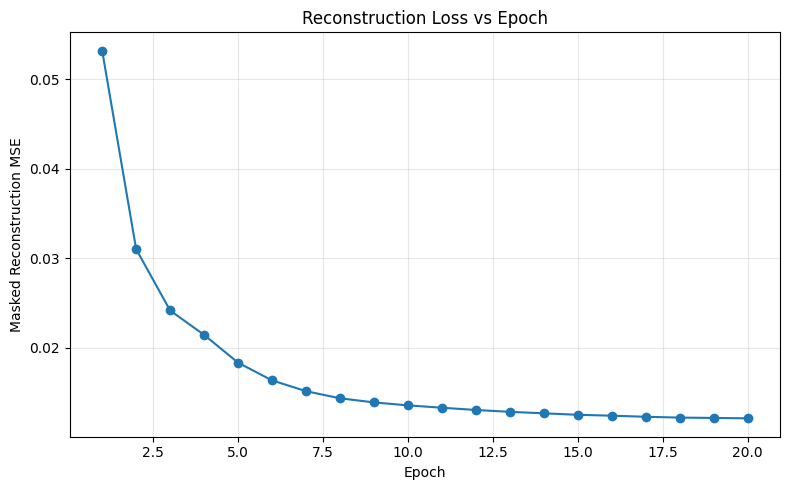

Saved: /kaggle/working/mae_outputs/train_loss.png


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Masked Reconstruction MSE')
plt.title('Reconstruction Loss vs Epoch')
plt.grid(alpha=0.3)
plt.tight_layout()
loss_plot_path = os.path.join(SAVE_DIR, 'train_loss.png')
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print('Saved:', loss_plot_path)


## Qualitative Reconstructions (5 samples)

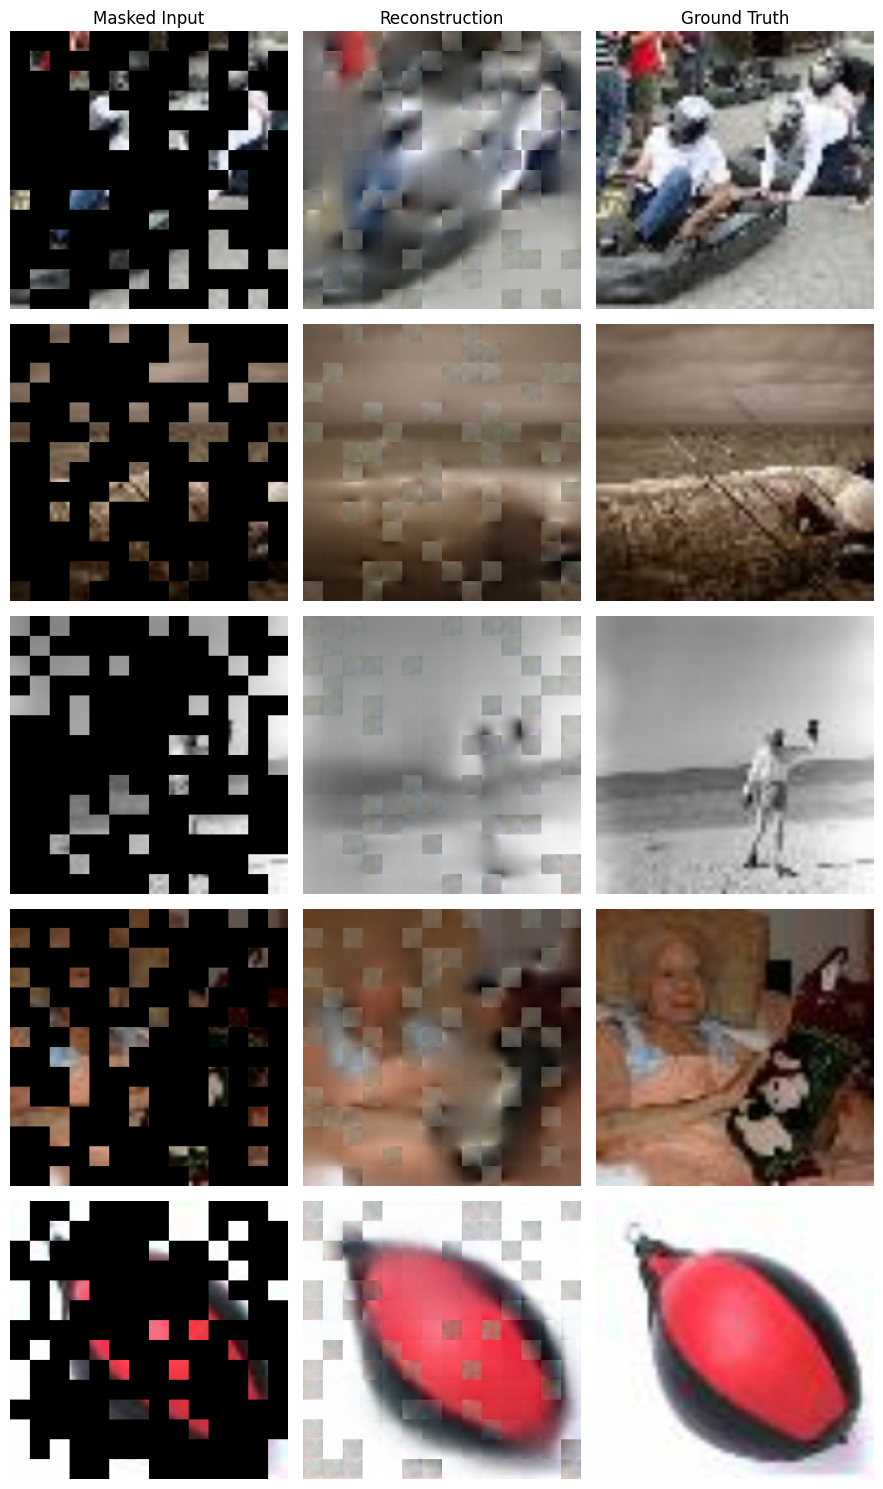

Saved: /kaggle/working/mae_outputs/recon_samples.png


In [ ]:
raw_model  = model.module if isinstance(model, nn.DataParallel) else model
recon_path = os.path.join(SAVE_DIR, 'recon_samples.png')
visualize_reconstructions(raw_model, val_loader, device, recon_path, n_samples=5)
print('Saved:', recon_path)


## Quantitative Evaluation (PSNR, SSIM)

In [ ]:
raw_model    = model.module if isinstance(model, nn.DataParallel) else model
psnr, ssim_v = evaluate_metrics(raw_model, val_loader, device, max_batches=10)
print(f'PSNR: {psnr:.4f}')
print(f'SSIM: {ssim_v:.4f}')

with open(os.path.join(SAVE_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write(f'PSNR: {psnr:.4f}\n')
    f.write(f'SSIM: {ssim_v:.4f}\n')

print('Saved:', os.path.join(SAVE_DIR, 'metrics.txt'))


PSNR: 18.3634
SSIM: 0.5260
Saved: /kaggle/working/mae_outputs/metrics.txt
